# Heart Risk Models
This notebook trains and evaluates several models (Logistic Regression, RandomForest, DecisionTree, XGBoost) on the heart dataset `heart_2022_clean.csv`.

In [3]:
import pandas as pd
import numpy as np

In [4]:
heart_df = pd.read_csv("../data/heart_2022_cleaned.csv")

In [5]:
heart_features = ['HeartDisease', 'Sex', 'AgeCategory', 'BMI', 'Smoking', 'PhysicalActivity',
    'AlcoholDrinking', 'MentalHealth', 'GenHealth', 'KidneyDisease',
    'SleepTime', 'DiffWalking', 'Asthma']
heart_df = heart_df[heart_features].copy()

In [6]:
heart_df["HeartDisease"] = (
    heart_df["HeartDisease"]
    .map({"No":0,"Yes":1})
)

In [7]:
X = heart_df.drop("HeartDisease", axis=1)
y = heart_df["HeartDisease"]

In [8]:
ordinal_cols = [
    "AgeCategory",
    "GenHealth"
]

nominal_cols = [
    "Sex",
    "Smoking",
    "PhysicalActivity",
    "AlcoholDrinking",
    "KidneyDisease",
    "DiffWalking",
    "Asthma",
    
]

numeric_cols = [
    "BMI",
    "MentalHealth",
    "SleepTime"
]

In [9]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split



In [10]:
tree_preprocessor = make_column_transformer(
    (OrdinalEncoder(), ordinal_cols),
    (OneHotEncoder(), nominal_cols),
    (StandardScaler(), numeric_cols)
)

lr_preprocessor = make_column_transformer(
    (
        OneHotEncoder(drop="first", handle_unknown="ignore"),
        ordinal_cols + nominal_cols
    ),
    (StandardScaler(), numeric_cols)
)

In [11]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_lr_train = lr_preprocessor.fit_transform(X_train_raw)
X_lr_test = lr_preprocessor.transform(X_test_raw)

X_tree_train = tree_preprocessor.fit_transform(X_train_raw)
X_tree_test = tree_preprocessor.transform(X_test_raw)

In [21]:
# Model training with SMOTE and hyperparameter tuning for LogisticRegression and XGBoost
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

# Apply SMOTE to address class imbalance before training (only for models we tune)
sm = SMOTE(random_state=42)
X_lr_train_smote, y_train_smote = sm.fit_resample(X_lr_train, y_train)
X_tree_train_smote, y_train_smote = sm.fit_resample(X_tree_train, y_train)

# Logistic Regression: tune regularization strength for better ROC AUC / recall
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
lr_search = RandomizedSearchCV(lr, param_grid_lr, scoring='roc_auc', cv=3, n_iter=5, random_state=42)
lr_search.fit(X_lr_train_smote, y_train_smote)
lr = lr_search.best_estimator_
print('Best LR params:', lr_search.best_params_)

# XGBoost: randomized search over common tree params (fit on SMOTE-resampled tree features)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
param_dist_xgb = {
    'n_estimators': [100, 200, 400],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight]
}
xgb_search = RandomizedSearchCV(xgb, param_dist_xgb, scoring='roc_auc', cv=3, n_iter=8, random_state=42, n_jobs=-1)
xgb_search.fit(X_tree_train_smote, y_train_smote)
xboost = xgb_search.best_estimator_
print('Best XGBoost params:', xgb_search.best_params_)

print('Trained/optimized models: LogisticRegression, XGBoost')


Best LR params: {'C': 0.1}
scale_pos_weight = 10.68


c:\Users\SAYAN GHOSH\Health_AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:06:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params: {'subsample': 0.8, 'scale_pos_weight': np.float64(10.683076080007307), 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1}
Trained/optimized models: LogisticRegression, XGBoost


In [22]:
# Evaluation function returning a metrics dict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {}
    metrics['model'] = name
    metrics['accuracy'] = accuracy_score(y_test, y_pred)
    metrics['precision'] = precision_score(y_test, y_pred, zero_division=0)
    metrics['recall'] = recall_score(y_test, y_pred, zero_division=0)
    metrics['f1'] = f1_score(y_test, y_pred, zero_division=0)
    # ROC AUC if probability available and binary classification
    try:
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_test)[:, 1]
            metrics['roc_auc'] = roc_auc_score(y_test, probs)
        else:
            metrics['roc_auc'] = np.nan
    except Exception:
        metrics['roc_auc'] = np.nan
    metrics['confusion_matrix'] = confusion_matrix(y_test, y_pred).tolist()
    return metrics


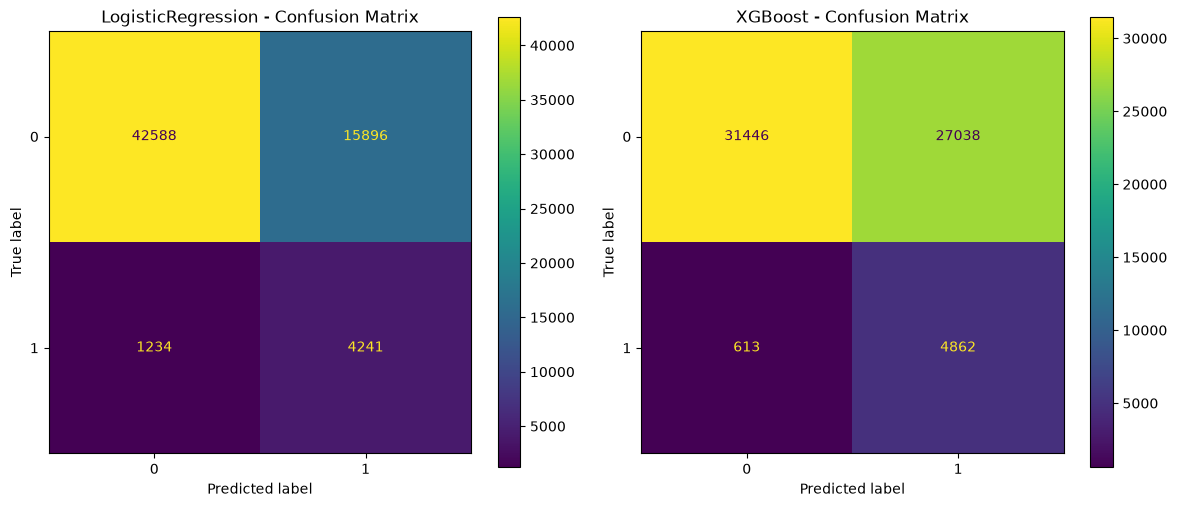

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

models = [
    ('LogisticRegression', lr, X_lr_test),
    ('XGBoost', xboost, X_tree_test)
]

for idx, (name, model, X_test) in enumerate(models):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[idx])
    axes[idx].set_title(f'{name} - Confusion Matrix')

plt.tight_layout()
plt.show()

In [24]:
# Compare models and build a summary table
import pandas as pd

results = []
results.append(evaluate_model('LogisticRegression', lr, X_lr_test, y_test))
results.append(evaluate_model('XGBoost', xboost, X_tree_test, y_test))

# Normalize results for display
rows = []
for r in results:
    rows.append({
        'model': r['model'],
        'accuracy': r['accuracy'],
        'precision': r['precision'],
        'recall': r['recall'],
        'f1': r['f1'],
        'roc_auc': r.get('roc_auc', np.nan)
    })

summary_df = pd.DataFrame(rows).set_index('model')
display(summary_df)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.732172,0.210607,0.774612,0.331173,0.826602
XGBoost,0.567676,0.152414,0.888037,0.260174,0.792976


In [25]:
# Class imbalance analysis
counts = y.value_counts()
pct = y.value_counts(normalize=True) * 100
imbalance_df = pd.DataFrame({'count': counts, 'percent': pct})
display(imbalance_df)

# Optional: show train/test imbalance
train_pct = y_train.value_counts(normalize=True) * 100
test_pct = y_test.value_counts(normalize=True) * 100
print("Train class %:")
print(train_pct)
print("Test class %:")
print(test_pct)


,count,percent
HeartDisease,,
0,292422,91.440454
1,27373,8.559546


Train class %:
HeartDisease
0    91.44061
1     8.55939
Name: proportion, dtype: float64
Test class %:
HeartDisease
0    91.439829
1     8.560171
Name: proportion, dtype: float64


In [26]:
# Threshold tuning for Logistic Regression
# compute positive probabilities
y_prob = lr.predict_proba(X_lr_test)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    rows.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1})

thr_df = pd.DataFrame(rows).set_index('threshold')
display(thr_df)

# Show example recalls
for t in [0.5, 0.2]:
    if t in thr_df.index:
        print(f"Threshold {t} - Recall = {thr_df.loc[t,'recall']:.2f}")


,precision,recall,f1
threshold,,,
0.1,0.109959,0.981735,0.197767
0.2,0.132079,0.952511,0.231989
0.3,0.155147,0.915068,0.265311
0.4,0.179993,0.853151,0.297270
0.5,0.210607,0.774612,0.331173


Threshold 0.5 - Recall = 0.77
Threshold 0.2 - Recall = 0.95


In [27]:
# Final model selection and summary
# Choose final threshold for logistic regression (based on tuning)
final_threshold = 0.2

y_prob = lr.predict_proba(X_lr_test)[:, 1]
y_pred_final = (y_prob >= final_threshold).astype(int)

from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

roc_auc = roc_auc_score(y_test, y_prob)
recall = recall_score(y_test, y_pred_final, zero_division=0)
precision = precision_score(y_test, y_pred_final, zero_division=0)
f1 = f1_score(y_test, y_pred_final, zero_division=0)

final_summary = pd.DataFrame({
    'metric': ['roc_auc', 'precision', 'recall', 'f1', 'threshold'],
    'value': [roc_auc, precision, recall, f1, final_threshold]
}).set_index('metric')

display(final_summary)

print('\nFinal Heart Model: Balanced Logistic Regression')
print(f'ROC-AUC = {roc_auc:.2f}')
print(f'Recall (threshold={final_threshold}) = {recall:.2f}')


,value
metric,
roc_auc,0.826602
precision,0.132079
recall,0.952511
f1,0.231989
threshold,0.200000



Final Heart Model: Balanced Logistic Regression
ROC-AUC = 0.83
Recall (threshold=0.2) = 0.95


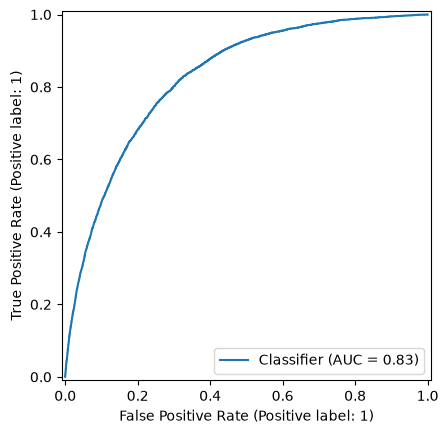

In [28]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

In [29]:
import os
import joblib

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(
    lr,
    os.path.join(MODELS_DIR, "heart_model.pkl")
)

joblib.dump(
    lr_preprocessor,
    os.path.join(MODELS_DIR, "heart_preprocessor.pkl")
)

joblib.dump(
    final_threshold,
    os.path.join(MODELS_DIR, "heart_threshold.pkl")
)

joblib.dump(
    X_train_raw.sample(1000, random_state=42),
    os.path.join(MODELS_DIR, "heart_background.pkl")
)

print("Heart model saved successfully!")

Heart model saved successfully!
